## Understand Spark Session & Create your First DataFrame | Create SparkSession object | Spark UI

In [ ]:
# Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
	.appName("Spark Introduction") \
	.master("local[*]") \
	.getOrCreate() # local[*] is to run Spark locally with as many worker threads as logical cores on your machine

spark

In [ ]:
emp_data = [
    ["001","101","John Doe","30","Male","50000","2015-01-01"],
    ["002","101","Jane Smith","25","Female","45000","2016-02-15"],
    ["003","102","Bob Brown","35","Male","55000","2014-05-01"],
    ["004","102","Alice Lee","28","Female","48000","2017-09-30"],
    ["005","103","Jack Chan","40","Male","60000","2013-04-01"],
    ["006","103","Jill Wong","32","Female","52000","2018-07-01"],
    ["007","101","James Johnson","42","Male","70000","2012-03-15"],
    ["008","102","Kate Kim","29","Female","51000","2019-10-01"],
    ["009","103","Tom Tan","33","Male","58000","2016-06-01"],
    ["010","104","Lisa Lee","27","Female","47000","2018-08-01"],
    ["011","104","David Park","38","Male","65000","2015-11-01"],
    ["012","105","Susan Chen","31","Female","54000","2017-02-15"],
    ["013","106","Brian Kim","45","Male","75000","2011-07-01"],
    ["014","107","Emily Lee","26","Female","46000","2019-01-01"],
    ["015","106","Michael Lee","37","Male","63000","2014-09-30"],
    ["016","107","Kelly Zhang","30","Female","49000","2018-04-01"],
    ["017","105","George Wang","34","Male","57000","2016-03-15"],
    ["018","104","Nancy Liu","29","","50000","2017-06-01"],
    ["019","103","Steven Chen","36","Male","62000","2015-08-01"],
    ["020","102","Grace Kim","32","Female","53000","2018-11-01"]
]

emp_schema = "employee_id string, department_id string, name string, age string, gender string, salary string, hire_date string"

In [ ]:
# Create DataFrame
emp = spark.createDataFrame(data=emp_data, schema=emp_schema)

In [ ]:
# Check no of partitions
emp.rdd.getNumPartitions()

In [ ]:
# Show data (ACTION)
emp.show(truncate=False)

In [ ]:
# Transformation (EMP Salary > 50000)
# emp_final = emp.filter(emp.salary > 50000)
emp_final = emp.where(emp.salary > 50000)

In [ ]:
# Validate no of Partitions
emp_final.rdd.getNumPartitions()

In [ ]:
# write data to CSV file
emp_final.write.format("csv").mode("overwrite").save("output/emp_salary_above_50000.csv")
# emp_final.show(truncate=False)
# mohit = spark.getActiveSession()

## Basic Structured Transformation - Part 1 | Write Spark DataFrame Schema | Ways to write DF Columns

In [ ]:
emp.printSchema()

In [ ]:
emp.schema

In [ ]:
# Small Example for Schema
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
schema_string = "name string, age int"

schema_spark =  StructType([
    StructField("name", StringType(), True),
    StructField("age", IntegerType(), True)
])

In [ ]:
# Columns and expression
from pyspark.sql.functions import col, expr

# col('name')
# expr('name')
# emp.salary
emp['name']

In [ ]:
# SELECT columns
# select employee_id, name, age, salary from emp

emp_filtered = emp.select(col("employee_id"), expr("name"), emp.age, emp["salary"])
emp_filtered.show(truncate=False) # Action

In [ ]:
# Using expr for select
# select employee_id as emp_id, name, cast(age as int) as age, salary from emp_filtered

emp_casted = emp_filtered.select(expr("employee_id as emp_id"), emp.name, expr("cast(age as int) as age"), emp.salary)
emp_casted.printSchema()

In [ ]:
emp_casted.show(truncate=False)

In [ ]:
# Using selectExpr for select
emp_casted_1 = emp_filtered.selectExpr("employee_id as emp_id", "name", "cast(age as int) as age", "salary")
emp_casted_1.show(truncate=False)

In [ ]:
emp_casted_1.printSchema()

In [ ]:
# Filter emp based on Age > 30
# select emp_id, name, age, salary from emp_casted where age > 30

emp_final_30 = emp_casted.select("emp_id", "name", "age", "salary").where("age > 30")

In [ ]:
# SHOW Dataframe (ACTION)
emp_final_30.show(truncate=False)

In [ ]:
# Write the data back as CSV (ACTION)
emp_final_30.write.format("csv").mode("overwrite").save("output/emp_age_above_30.csv")

In [ ]:
# Bonus TIP

schema_str = "name string, age int"

from pyspark.sql.types import _parse_datatype_string

schema_spark = _parse_datatype_string(schema_str)

schema_spark

## Basic Structured Transformation - Part 2 | Cast Column | Add Column | Static Column Value | Rename

In [ ]:
# Casting Column
# select employee_id, name, age, cast(salary as double) as salary from emp
from pyspark.sql.functions import col, cast

emp_casted = emp.select("employee_id", "name", "age", col("salary").cast("double"))
emp_casted.printSchema()

In [ ]:
# Adding Columns
# select employee_id, name, age, salary, (salary * 0.2) as tax from emp_casted

emp_taxed = emp_casted.withColumn("tax", col("salary") * 0.2)
emp_taxed.show(truncate=False)

In [ ]:
# Literals
# select employee_id, name, age, salary, tax, 1 as columnOne, 'two' as columnTwo from emp_taxed
from pyspark.sql.functions import lit

emp_new_cols = emp_taxed.withColumn("columnOne", lit(1)).withColumn("columnTwo", lit('two'))
emp_new_cols.show(truncate=False)

In [ ]:
# Renaming Columns
# select employee_id as emp_id, name, age, salary, tax, columnOne, columnTwo from emp_new_cols

emp_1 = emp_new_cols.withColumnRenamed("employee_id", "emp_id")
emp_1.show(truncate=False)

In [ ]:
# Column names with Spaces
# select employee_id as emp_id, name, age, salary, tax, columnOne, columnTwo as `Column Two` from emp_new_cols

emp_2 = emp_new_cols.withColumnRenamed("columnTwo", "Column Two")
emp_2.show(truncate=False)

In [ ]:
# Remove Column

emp_dropped = emp_new_cols.drop("columnTwo", "columnOne")
emp_dropped.show(truncate=False)

In [ ]:
# Filter data
# select employee_id as emp_id, name, age, salary, tax, columnOne from emp_col_dropped where tax > 1000

emp_filtered = emp_dropped.where("tax > 10000")
emp_filtered.show(truncate=False)

In [ ]:
# LIMIT data
# select employee_id as emp_id, name, age, salary, tax, columnOne from emp_filtered limit 5

emp_limit = emp_filtered.limit(5)
emp_limit.show(2,truncate=False)

In [ ]:
# Bonus TIP
# Add multiple columns

columns = {
    "tax" : col("salary") * 0.2 ,
    "oneNumber" : lit(1),
    "columnTwo" : lit("two")
}

emp_final = emp.withColumns(columns)
emp_final.show(truncate=False)

## Working with Strings, Dates and Null | Regex Replace | Convert string to date | Transform NULL

In [ ]:
# Case When
# select employee_id, name, age, salary, gender,
# case when gender = 'Male' then 'M' when gender = 'Female' then 'F' else null end as new_gender, hire_date from emp
from pyspark.sql.functions import when, col, expr

emp_gender_fixed = emp.withColumn("new_gender", when(col("gender") == 'Male', 'M')
                                 			   .when(col("gender") == 'Female', 'F')
                                 			   .otherwise(None)
                                 )

# emp_gender_fixed_1 = emp.withColumn("new_gender", expr("case when gender = 'Male' then 'M' when gender = 'Female' then 'F' else null end"))
emp_gender_fixed.show(truncate=False)

In [ ]:
# Replace in Strings
# select employee_id, name, replace(name, 'J', 'Z') as new_name, age, salary, gender, new_gender, hire_date from emp_gender_fixed
from pyspark.sql.functions import regexp_replace

emp_name_fixed = emp_gender_fixed.withColumn("new_name", regexp_replace(col("name"), "J", "Z"))
emp_name_fixed.show(truncate=False)

In [ ]:
# Convert Date
# select *,  to_date(hire_date, 'YYYY-MM-DD') as hire_date from emp_name_fixed
from pyspark.sql.functions import to_date

emp_date_fix = emp_name_fixed.withColumn("hire_date", to_date(col("hire_date"), 'yyyy-MM-dd'))
emp_date_fix.show(truncate=False)

In [ ]:
emp_date_fix.printSchema()

In [ ]:
# Add Date Columns
# Add current_date, current_timestamp, extract year from hire_date
from pyspark.sql.functions import current_date, current_timestamp

emp_dated = emp_date_fix.withColumn("date_now", current_date()).withColumn("timestamp_now", current_timestamp())
emp_dated.show(truncate=False)

In [ ]:
# Drop Null gender records
emp_1 = emp_dated.na.drop()
emp_1.show(truncate=False)

In [ ]:
# Fix Null values
# select *, nvl('new_gender', 'O') as new_gender from emp_dated
from pyspark.sql.functions import coalesce, lit

emp_null_df = emp_dated.withColumn("new_gender", coalesce(col("new_gender"), lit("O")))
emp_null_df.show(truncate=False)

In [ ]:
# Drop old columns and Fix new column names
emp_final = emp_null_df.drop("name", "gender").withColumnRenamed("new_name", "name").withColumnRenamed("new_gender", "gender")
emp_final.show(truncate=False)

In [ ]:
# Write data as CSV
emp_final.write.format("csv").mode("overwrite").save("output/emp.csv")

In [ ]:
# Bonus TIP
# Convert date into String and extract date information
from pyspark.sql.functions import date_format

# emp_fixed_date = emp_final.withColumn("date_str", date_format(col("hire_date"), "dd/MM/yyyy"))
# emp_fixed_date.show(truncate=False)
emp_fixed_yr = emp_final.withColumn("date_year", date_format(col("timestamp_now"), "z"))
emp_fixed_yr.show(truncate=False)

In [ ]:
# Clearing Spark Session and df variables
del emp, emp_final, emp_filtered, emp_casted, emp_casted_1, emp_final_30, emp_taxed, emp_new_cols, emp_1, emp_2, emp_dropped, emp_limit, emp_gender_fixed, emp_name_fixed, emp_date_fix, emp_dated, emp_null_df, emp_fixed_yr

## Sorting data, Union and Aggregation in Spark | Difference in Union and UnionAll | Having Clause

In [ ]:
# Emp Data & Schema
emp_data_1 = [
    ["001","101","John Doe","30","Male","50000","2015-01-01"],
    ["002","101","Jane Smith","25","Female","45000","2016-02-15"],
    ["003","102","Bob Brown","35","Male","55000","2014-05-01"],
    ["004","102","Alice Lee","28","Female","48000","2017-09-30"],
    ["005","103","Jack Chan","40","Male","60000","2013-04-01"],
    ["006","103","Jill Wong","32","Female","52000","2018-07-01"],
    ["007","101","James Johnson","42","Male","70000","2012-03-15"],
    ["008","102","Kate Kim","29","Female","51000","2019-10-01"],
    ["009","103","Tom Tan","33","Male","58000","2016-06-01"],
    ["010","104","Lisa Lee","27","Female","47000","2018-08-01"]
]

emp_data_2 = [
    ["011","104","David Park","38","Male","65000","2015-11-01"],
    ["012","105","Susan Chen","31","Female","54000","2017-02-15"],
    ["013","106","Brian Kim","45","Male","75000","2011-07-01"],
    ["014","107","Emily Lee","26","Female","46000","2019-01-01"],
    ["015","106","Michael Lee","37","Male","63000","2014-09-30"],
    ["016","107","Kelly Zhang","30","Female","49000","2018-04-01"],
    ["017","105","George Wang","34","Male","57000","2016-03-15"],
    ["018","104","Nancy Liu","29","","50000","2017-06-01"],
    ["019","103","Steven Chen","36","Male","62000","2015-08-01"],
    ["020","102","Grace Kim","32","Female","53000","2018-11-01"]
]

emp_schema = "employee_id string, department_id string, name string, age string, gender string, salary string, hire_date string"

# Create emp DataFrame
emp_data_1 = spark.createDataFrame(data=emp_data_1, schema=emp_schema)
emp_data_2 = spark.createDataFrame(data=emp_data_2, schema=emp_schema)

# Show emp dataframe (ACTION)
emp_data_1.show()
emp_data_2.show()

In [ ]:
# Print Schema
emp_data_1.printSchema()
emp_data_2.printSchema()

In [ ]:
# UNION and UNION ALL
# select * from emp_data_1 UNION select * from emp_data_2
emp = emp_data_1.unionAll(emp_data_2)
emp.show(truncate=False)

In [ ]:
# Sort the emp data based on desc Salary
# select * from emp order by salary desc
from pyspark.sql.functions import desc, asc, col

emp_sorted = emp.orderBy(col("salary").asc())
emp_sorted.show(truncate=False)

In [ ]:
# Aggregation
# select dept_id, count(employee_id) as total_dept_count from emp_sorted group by dept_id
from pyspark.sql.functions import count

emp_count = emp_sorted.groupBy("department_id").agg(count("employee_id").alias("total_dept_count"))
emp_count.show(truncate=False)

In [ ]:
# Aggregation
# select dept_id, sum(salary) as total_dept_salary from emp_sorted group by dept_id
from pyspark.sql.functions import sum

emp_sum = emp_sorted.groupBy("department_id").agg(sum("salary").alias("total_dept_salary"))
emp_sum.show(truncate=False)

In [ ]:
# Aggregation with having clause
# select dept_id, avg(salary) as avg_dept_salary from emp_sorted  group by dept_id having avg(salary) > 50000
from pyspark.sql.functions import avg

emp_avg = emp_sorted.groupBy("department_id").agg(avg("salary").alias("avg_dept_salary")).where("avg_dept_salary > 50000")
emp_avg.show(truncate=False)

In [ ]:
# Bonus TIP - unionByName
# In case the column sequence is different
emp_data_2_other = emp_data_2.select("employee_id", "salary", "department_id", "name", "hire_date", "gender", "age")

emp_data_1.printSchema()
emp_data_2_other.printSchema()

In [ ]:
emp_fixed = emp_data_1.unionByName(emp_data_2_other)
emp_fixed.show(truncate=False)

In [ ]:
emp.count()

## Window Functions, Unique Data & Databricks Community Cloud | Second Highest Salary | Spark expr

In [ ]:
# Get unique data
# select distinct emp.* from emp
emp_unique = emp.distinct()
emp_unique.show()

In [ ]:
# Unique of department_ids
# select distinct department_id from emp
emp_dept_id = emp.select("department_id").distinct()
emp_dept_id.show()

In [ ]:
# Window Functions
# select *, max(salary) over(partition by department_id order by salary desc) as max_salary from emp_unique
from pyspark.sql.window import Window
from pyspark.sql.functions import max, col, desc

window_spec = Window.partitionBy(col("department_id")).orderBy(col("salary").desc())
max_func = max(col("salary")).over(window_spec)

emp_1 = emp.withColumn("max_salary", max_func)
emp_1.show(truncate=False)

In [ ]:
# Window Functions - 2nd highest salary of each department
# select *, row_number() over(partition by department_id order by salary desc) as rn from emp_unique where rn = 2
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc, col

window_spec = Window.partitionBy(col("department_id")).orderBy(col("salary").desc())
rn = row_number().over(window_spec)

emp_2 = emp.withColumn("rn", rn).where("rn = 2")
emp_2.show(truncate=False)

In [ ]:
# Window function using expr
# select *, row_number() over(partition by department_id order by salary desc) as rn from emp_unique where rn = 2
from pyspark.sql.functions import expr

emp_3 = emp.withColumn("rn", expr("row_number() over(partition by department_id order by salary desc)")).where("rn = 2")
emp_3.show(truncate=False)

In [ ]:
# Bonus tip
# Databricks community page

## Data Repartitioning & PySpark Joins | Coalesce vs Repartition | Spark Data Partition | Joins

In [ ]:
dept_data = [
    ["101", "Sales", "NYC", "US", "1000000"],
    ["102", "Marketing", "LA", "US", "900000"],
    ["103", "Finance", "London", "UK", "1200000"],
    ["104", "Engineering", "Beijing", "China", "1500000"],
    ["105", "Human Resources", "Tokyo", "Japan", "800000"],
    ["106", "Research and Development", "Perth", "Australia", "1100000"],
    ["107", "Customer Service", "Sydney", "Australia", "950000"]
]

dept_schema = "department_id string, department_name string, city string, country string, budget string"

In [ ]:
# Create dept DataFrame
dept = spark.createDataFrame(dept_data, schema=dept_schema)
dept.show(truncate=False)
dept.printSchema()

In [ ]:
# Get number of partitions for emp
emp.rdd.getNumPartitions()

In [ ]:
# Get number of partitions for dept
dept.rdd.getNumPartitions()

In [ ]:
# Repartition of data using repartition & coalesce
# emp_partitioned = emp.repartition(4) # Repartition into 4 partitions
emp_partitioned = emp.repartition(4, "department_id") # Repartition based on department_id into 4 partitions
emp_partitioned.rdd.getNumPartitions()

In [ ]:
emp_coalesced = emp_partitioned.coalesce(2)
emp_coalesced.rdd.getNumPartitions()

In [ ]:
# Find the partition info for partitions and reparition
from pyspark.sql.functions import spark_partition_id
emp_1 = emp.withColumn("partition_num", spark_partition_id())
emp_1.show(truncate=False)

In [ ]:
emp_1 = emp.repartition(4, "department_id").withColumn("partition_num", spark_partition_id())
emp_1.show(truncate=False)

In [ ]:
# INNER JOIN datasets
# select e.emp_name, d.department_name, d.department_id, e.salary
# from emp e inner join dept d on emp.department_id = dept.department_id

df_joined = emp.alias("e").join(dept.alias("d"), how="inner", on=emp.department_id==dept.department_id)
df_joined.select("e.name", "d.department_id", "d.department_name", "e.salary").show()

In [ ]:
# LEFT OUTER JOIN datasets
# select e.emp_name, d.department_name, d.department_id, e.salary
# from emp e left outer join dept d on emp.department_id = dept.department_id

df_joined = emp.alias("e").join(dept.alias("d"), how="left_outer", on=emp.department_id==dept.department_id)
df_joined.select("e.name", "d.department_name", "d.department_id", "e.salary").show()

In [ ]:
# Bonus TIP
# Joins with cascading conditions
# Join with Department_id and only for departments 101 or 102
# Join with not null/null conditions

df_final = emp.join(dept, how="left_outer",
                   		  on=(emp.department_id==dept.department_id)
                          & ((emp.department_id == "101") | (emp.department_id == "102"))
                		  & (emp.salary.isNotNull())
                   )
df_final.show(truncate=False)

In [ ]:
# Clear dataframes
del emp_data_1, emp_data_2, emp_data_2_other, emp, emp_sorted, emp_count, emp_sum, emp_avg, emp_fixed, emp_unique, emp_dept_id, emp_1, emp_2, emp_3, dept, df_joined, df_final

## Understand Spark UI, Read CSV Files and Read Modes | Spark InferSchema Option | Drop Malformed

In [ ]:
# Read a csv file into dataframe
df = spark.read.format("csv").option("header", True).option("inferSchema", True).load("output/emp1.csv")
df.printSchema()

In [ ]:
df.show(truncate=False)

In [ ]:
# Reading with Schema
_schema = "employee_id int, department_id int, name string, age int, gender string, salary double, hire_date date"

df_schema = spark.read.format("csv").option("header",True).schema(_schema).load("output/emp1.csv")
df_schema.show(truncate=False)

In [ ]:
# Handle BAD records - PERMISSIVE (Default mode)
_schema = "employee_id int, department_id int, name string, age int, gender string, salary double, hire_date date, bad_record string"

df_p = spark.read.format("csv").schema(_schema).option("columnNameOfCorruptRecord", "bad_record").option("header", True).load("output/emp_new.csv")

In [ ]:
df_p.printSchema()

In [ ]:
# df_p.show(truncate=False)
df_p.where(col("bad_record").isNull()).show(truncate=False)

In [ ]:
# Handle BAD records - DROPMALFORMED
_schema = "employee_id int, department_id int, name string, age int, gender string, salary double, hire_date date"

df_m = spark.read.format("csv").option("header", True).option("mode", "DROPMALFORMED").schema(_schema).load("output/emp_new.csv")

In [ ]:
df_m.show(truncate=False)

In [ ]:
# Handle BAD records - FAILFAST
_schema = "employee_id int, department_id int, name string, age int, gender string, salary double, hire_date date"

df_m = spark.read.format("csv").option("header", True).option("mode", "FAILFAST").schema(_schema).load("output/emp_new.csv")

In [ ]:
# df_m.show(truncate=False) # This fails the job if there are BAD records

In [ ]:
# BONUS TIP
# Multiple options
_options = {
    "header" : "true",
    "inferSchema" : "true",
    "mode" : "PERMISSIVE"
}

df = (spark.read.format("csv").options(**_options).load("output/emp1.csv"))
df.show(truncate=False)

In [ ]:
# Clear dataframes
del df, df_p, df_m

## Read Complex File Formats | Parquet | ORC | Performance benefit of Parquet | Recursive File Lookup
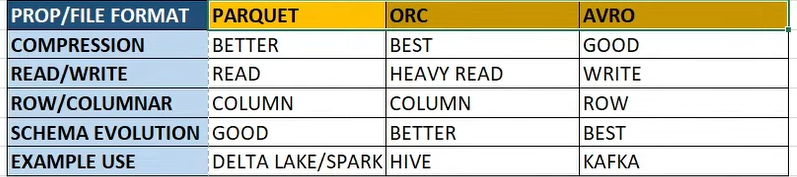

In [ ]:
# Read Parquet Sales data
df_parquet = spark.read.format("parquet").load("input/sales_data.parquet") # For reading the whole directory full of parquet files, we can just give the directory path and then *.parquet
df_parquet.printSchema()

In [ ]:
df_parquet.show(truncate=False)

In [ ]:
# Read ORC Sales data
df_orc = spark.read.format("orc").load("input/sales_data.orc")
df_orc.printSchema()

In [ ]:
df_orc.show(truncate=False)

In [ ]:
# Benefits of Columnar Storage

# Lets create a simple Python decorator - {get_time} to get the execution timings
# If you dont know about Python decorators - check out : https://www.geeksforgeeks.org/decorators-in-python/
import time

def get_time(func):
    def inner_get_time() -> str:
        start_time = time.time()
        func()
        end_time = time.time()
        return (f"Execution time: {(end_time - start_time)*1000} ms")
    print(inner_get_time())

In [ ]:
@get_time
def x():
    df = spark.read.format("parquet").load("input/sales_data.parquet")
    df.count()

In [ ]:
@get_time
def x():
    df = spark.read.format("parquet").load("input/sales_data.parquet")
    df.select("trx_id").count()

In [ ]:
# BONUS TIP
# RECURSIVE READ

# sales_recursive
# |__ sales_1\1.parquet
# |__ sales_1\sales_2\2.parquet

# df_1 = spark.read.format("parquet").option("recursiveFileLookup", True).load("datasets/sales_recursive/")
# df_1.show()

In [ ]:
# Clear dataframes
del df_parquet, df_orc

## Read, Parse or Flatten JSON data | JSON file with Schema | from_json | to_json | Multiline JSON

In [ ]:
# Read Single line JSON file
df_single = spark.read.format("json").load("input/order_singleline.json")
df_single.printSchema()

In [ ]:
df_single.show()

In [ ]:
# Read Multiline JSON file

df_multi = spark.read.format("json").option("multiLine", True).load("input/order_multiline.json")
df_multi.printSchema()

In [ ]:
df_multi.show(truncate=False)

In [ ]:
df = spark.read.format("text").load("input/order_singleline.json")
df.printSchema()

In [ ]:
df.show(truncate=False)

In [ ]:
# With Schema

_schema = "customer_id string, order_id string, contact array<long>"

df_schema = spark.read.format("json").schema(_schema).load("input/order_singleline.json")
df_schema.show(truncate=False)

In [ ]:
_schema = "contact array<string>, customer_id string, order_id string, order_line_items array<struct<amount double, item_id string, qty long>>"
df_schema_new = spark.read.format("json").schema(_schema).load("input/order_singleline.json")
df_schema_new.printSchema()

In [ ]:
df_schema_new.show(truncate=False)

In [ ]:
df.show(truncate=False)

In [ ]:
# Function from_json to read from a column

_schema = "contact array<string>, customer_id string, order_id string, order_line_items array<struct<amount double, item_id string, qty long>>"

from pyspark.sql.functions import from_json

df_expanded = df.withColumn("parsed", from_json(df.value, _schema))
df_expanded.printSchema()

In [ ]:
df_expanded.show()

In [ ]:
# Function to_json to parse a JSON string
from pyspark.sql.functions import to_json

df_unparsed = df_expanded.withColumn("unparsed", to_json(df_expanded.parsed))
df_unparsed.printSchema()

In [ ]:
df_unparsed.select("unparsed").show(truncate=False)

In [ ]:
# Get values from Parsed JSON
df_1 = df_expanded.select("parsed.*")
df_1.show(truncate=False)

In [ ]:
from pyspark.sql.functions import explode

df_2 = df_1.withColumn("expanded_line_items", explode("order_line_items"))
df_2.show(truncate=False)

In [ ]:
df_3 = df_2.select("contact", "customer_id", "order_id", "expanded_line_items.*")
# df_3 = df_2.select("contact", "customer_id", "order_id", "expanded_line_items.item_id")
df_3.show(truncate=False)

In [ ]:
# Explode Array fields
df_final = df_3.withColumn("contact_expanded", explode("contact"))
df_final.printSchema()

In [ ]:
df_final.drop("contact").show(truncate=False)

In [ ]:
# Clear dataframes
del df_single, df_multi, df, df_schema, df_schema_new, df_expanded, df_unparsed, df_1, df_2, df_3, df_final

### Vid 15th is members only now
## How Spark Writes data | Write modes in Spark | Write data with Partition | Default Parallelism

In [ ]:
# Spark available cores with defaultParallism in Spark UI
spark.sparkContext.defaultParallelism

In [ ]:
emp_schema

In [ ]:
# Spark available cores with defaultParallism in Spark UI
spark.sparkContext.defaultParallelism

In [ ]:
# Create emp DataFrame
emp = spark.createDataFrame(data=emp_data, schema=emp_schema)

In [ ]:
# Get number of partitions and show data
emp.rdd.getNumPartitions()

In [ ]:
emp.show()

In [ ]:
# Write the data in parquet format
emp.write.mode("overwrite").format("parquet").save("output/emp.parquet")

In [ ]:
# View data partition information
from pyspark.sql.functions import spark_partition_id

emp.withColumn("partition_id", spark_partition_id()).show()

In [ ]:
emp.write.format("csv").option("header", True).mode("overwrite").save("output/emp.csv")

In [ ]:
# Write the data with Partition to output location
emp.write.mode("overwrite").format("csv").partitionBy("department_id").option("header", True).save("output/emp_dept.csv")

In [ ]:
# Bonus TIP
# What if we need to write only 1 output file to share with DownStream?
emp.repartition(1).write.mode("overwrite").format("csv").option("header", True).save("output/emp_single.csv")

In [ ]:
# Clear dataframes
del emp
# Stop Spark Session
spark.stop()

## Understand Spark Execution on Cluster | Cluster Manager | Cluster Deployment Modes | Spark Submit

In [ ]:
# Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
	.appName("Cluster Execution") \
	.master("spark://spark-master:7077") \
    .config("spark.executor.instances", 4) \
    .config("spark.executor.cores", 4) \
    .config("spark.executor.memory", "512M") \
	.getOrCreate() # local[*] is to run Spark locally with as many worker threads as logical cores on your machine

spark

In [ ]:
# Create a sample data frame
df = spark.range(10)

In [ ]:
# Write the data of the data frame
df.write.mode("overwrite").format("csv").option("header", True).save("output/range.csv")

In [ ]:
# Stop Spark Session
spark.stop()

Executing form command line terminal.<br />
/spark# ./bin/spark-submit --master spark://spark-master:7077 --num-executors 3 --executor-cores 2 --executor-memory 512M /data/understand_cluser.py

## User Defined Function (UDF) | How Spark works with UDF | How to register Python UDF

In [1]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("User Defined Functions")
    .master("spark://spark-master:7077")
    .config("spark.executor.cores", 2)
    .config("spark.cores.max", 6)
    .config("spark.executor.memory", "512M")
    .getOrCreate()
)

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/27 17:36:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Read employee data
emp_schema = "employee_id string, department_id string, name string, age string, gender string, salary string, hire_date string"

emp = spark.read.format("csv").option("header", True).schema(emp_schema).load("./datasets/emp.csv")

emp.rdd.getNumPartitions()

1

In [3]:
# Create a function to generate 10% of Salary as Bonus

def bonus(salary):
    return int(salary) * 0.1

In [6]:
# Register as UDF
from pyspark.sql.functions import udf

bonus_udf = udf(bonus)

# register takes 3 parameters - name of the UDF, function and return type
spark.udf.register("bonus_sql_udf", bonus, "double")

<function __main__.bonus(salary)>

In [7]:
# Create new column as bonus using UDF
from pyspark.sql.functions import expr

# emp.withColumn("bonus", bonus_udf("salary")).show()
emp.withColumn("bonus", expr("bonus_sql_udf(salary)")).show()

+-----------+-------------+-------------+---+------+------+----------+------+
|employee_id|department_id|         name|age|gender|salary| hire_date| bonus|
+-----------+-------------+-------------+---+------+------+----------+------+
|        001|          101|     John Doe| 30|  Male| 50000|2015-01-01|5000.0|
|        002|          101|   Jane Smith| 25|Female| 45000|2016-02-15|4500.0|
|        003|          102|    Bob Brown| 35|  Male| 55000|2014-05-01|5500.0|
|        004|          102|    Alice Lee| 28|Female| 48000|2017-09-30|4800.0|
|        005|          103|    Jack Chan| 40|  Male| 60000|2013-04-01|6000.0|
|        006|          103|    Jill Wong| 32|Female| 52000|2018-07-01|5200.0|
|        007|          101|James Johnson| 42|  Male| 70000|2012-03-15|7000.0|
|        008|          102|     Kate Kim| 29|Female| 51000|2019-10-01|5100.0|
|        009|          103|      Tom Tan| 33|  Male| 58000|2016-06-01|5800.0|
|        010|          104|     Lisa Lee| 27|Female| 47000|2018-

In [8]:
# Create new column as bonus without UDF as UDF is expensive
emp.withColumn("bonus", expr("salary * 0.1")).show()

+-----------+-------------+-------------+---+------+------+----------+------+
|employee_id|department_id|         name|age|gender|salary| hire_date| bonus|
+-----------+-------------+-------------+---+------+------+----------+------+
|        001|          101|     John Doe| 30|  Male| 50000|2015-01-01|5000.0|
|        002|          101|   Jane Smith| 25|Female| 45000|2016-02-15|4500.0|
|        003|          102|    Bob Brown| 35|  Male| 55000|2014-05-01|5500.0|
|        004|          102|    Alice Lee| 28|Female| 48000|2017-09-30|4800.0|
|        005|          103|    Jack Chan| 40|  Male| 60000|2013-04-01|6000.0|
|        006|          103|    Jill Wong| 32|Female| 52000|2018-07-01|5200.0|
|        007|          101|James Johnson| 42|  Male| 70000|2012-03-15|7000.0|
|        008|          102|     Kate Kim| 29|Female| 51000|2019-10-01|5100.0|
|        009|          103|      Tom Tan| 33|  Male| 58000|2016-06-01|5800.0|
|        010|          104|     Lisa Lee| 27|Female| 47000|2018-

In [9]:
# Clear dataframes
del emp

In [10]:
# Stop Spark Session
spark.stop()

## Understand DAG, Explain Plans & Spark Shuffle with Tasks | Skipped Stage | Benefit of Shuffle Write

In [11]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Understand Plans and DAG")
    .master("local[*]")
    .getOrCreate()
)

spark

In [12]:
# Disable AQE(Adaptive Query Execution) and Broadcast join

spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

In [13]:
# Check default Parallism

spark.sparkContext.defaultParallelism

8

In [14]:
# Create dataframes

df_1 = spark.range(4, 200, 2)
df_2 = spark.range(2, 200, 4)

In [16]:
# df_1.rdd.getNumPartitions()
df_2.rdd.getNumPartitions()

8

In [17]:
# Re-partition data

df_3 = df_1.repartition(5)
df_4 = df_2.repartition(7)

In [19]:
# df_3.rdd.getNumPartitions()
df_4.rdd.getNumPartitions()

7

In [20]:
# Join the dataframes

df_joined = df_3.join(df_4, on="id")

In [21]:
# Get the sum of ids

df_sum = df_joined.selectExpr("sum(id) as total_sum")

In [22]:
# View data
df_sum.show()

+---------+
|total_sum|
+---------+
|     4998|
+---------+



In [ ]:
# Explain plan
# Default shuffle partition number is 200 in Spark, so if the data is less than that, it will create empty partitions which can lead to performance issues. So we can set the shuffle partition number to a lower value to avoid this issue.
df_sum.explain()

== Physical Plan ==
*(6) HashAggregate(keys=[], functions=[sum(id#173L)])
+- Exchange SinglePartition, ENSURE_REQUIREMENTS, [plan_id=249]
   +- *(5) HashAggregate(keys=[], functions=[partial_sum(id#173L)])
      +- *(5) Project [id#173L]
         +- *(5) SortMergeJoin [id#173L], [id#175L], Inner
            :- *(2) Sort [id#173L ASC NULLS FIRST], false, 0
            :  +- Exchange hashpartitioning(id#173L, 200), ENSURE_REQUIREMENTS, [plan_id=233]
            :     +- Exchange RoundRobinPartitioning(5), REPARTITION_BY_NUM, [plan_id=232]
            :        +- *(1) Range (4, 200, step=2, splits=8)
            +- *(4) Sort [id#175L ASC NULLS FIRST], false, 0
               +- Exchange hashpartitioning(id#175L, 200), ENSURE_REQUIREMENTS, [plan_id=240]
                  +- Exchange RoundRobinPartitioning(7), REPARTITION_BY_NUM, [plan_id=239]
                     +- *(3) Range (2, 200, step=4, splits=8)




In [24]:
# Union the data again to see the skipped stages

df_union = df_sum.union(df_4)

In [25]:
df_union.show()

+---------+
|total_sum|
+---------+
|     4998|
|        2|
|       46|
|       58|
|       90|
|      102|
|      138|
|      158|
|      194|
|       18|
|       38|
|       74|
|      166|
|      174|
|       30|
|       66|
|       98|
|      122|
|      146|
|      162|
+---------+
only showing top 20 rows



In [26]:
# Explain plan

df_union.explain()

== Physical Plan ==
Union
:- *(6) HashAggregate(keys=[], functions=[sum(id#173L)])
:  +- Exchange SinglePartition, ENSURE_REQUIREMENTS, [plan_id=487]
:     +- *(5) HashAggregate(keys=[], functions=[partial_sum(id#173L)])
:        +- *(5) Project [id#173L]
:           +- *(5) SortMergeJoin [id#173L], [id#175L], Inner
:              :- *(2) Sort [id#173L ASC NULLS FIRST], false, 0
:              :  +- Exchange hashpartitioning(id#173L, 200), ENSURE_REQUIREMENTS, [plan_id=471]
:              :     +- Exchange RoundRobinPartitioning(5), REPARTITION_BY_NUM, [plan_id=470]
:              :        +- *(1) Range (4, 200, step=2, splits=8)
:              +- *(4) Sort [id#175L ASC NULLS FIRST], false, 0
:                 +- Exchange hashpartitioning(id#175L, 200), ENSURE_REQUIREMENTS, [plan_id=478]
:                    +- Exchange RoundRobinPartitioning(7), REPARTITION_BY_NUM, [plan_id=477]
:                       +- *(3) Range (2, 200, step=4, splits=8)
+- ReusedExchange [id#194L], Exchange Roun

RDD - Resilient distributed data<br />

In [27]:
# DataFrame to RDD

df_1.rdd

MapPartitionsRDD[5] at javaToPython at NativeMethodAccessorImpl.java:0

In [28]:
# Clear dataframes
del df_1, df_2, df_3, df_4, df_joined, df_sum, df_union

In [29]:
# Stop Spark Session
spark.stop()

## Understand and Optimize Shuffle in Spark
Shuffle files are seralized into tungsten binary format(unsafe row format). Pipeline are stages. Narrow transformations are clubbed together and operations performed in pipeline. Shuffle files are written to discs. Avoid shuffle where ever possible as disc io operations and network operations are expensive.

In [ ]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Optimizing Shuffles")
    .master("spark://spark-master:7077")
    .config("spark.cores.max", 16)
    .config("spark.executor.cores", 4)
    .config("spark.executor.memory", "512M")
    .getOrCreate()
)

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/28 15:58:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/05/28 15:58:22 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [3]:
# Check Spark defaultParallelism

spark.sparkContext.defaultParallelism

16

In [4]:
# Disable AQE and Broadcast join

spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

In [5]:
# Read EMP CSV file with 10M records
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"

emp = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/employee_records.csv")

In [6]:
# Find out avg salary as per dept
from pyspark.sql.functions import avg

emp_avg = emp.groupBy("department_id").agg(avg("salary").alias("avg_sal"))

In [10]:
# Write data for performance Benchmarking

emp_avg.write.format("noop").mode("overwrite").save()

In [11]:
# Check Spark Shuffle Partition setting

spark.conf.get("spark.sql.shuffle.partitions")

'16'

In [9]:
spark.conf.set("spark.sql.shuffle.partitions", 16)

In [12]:
from pyspark.sql.functions import spark_partition_id

emp.withColumn("partition_id", spark_partition_id()).where("partition_id = 0").show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|partition_id|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|           0|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|           0|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|           0|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|           0|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|tiffany

In [ ]:
# Read the partitioned data
# emp_part = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/emp_partitioned.csv")
# emp_avg = emp_part.groupBy("department_id").agg(avg("salary").alias("avg_sal"))
# emp_avg.write.format("noop").mode("overwrite").save()

In [13]:
# Clear dataframes
del emp, emp_avg
# Stop Spark Session
spark.stop()

## Data Caching in Spark | Cache vs Persist | Spark Storage Level with Persist | Partial Data Caching

In [ ]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Understand Caching")
    .master("local[*]")
    .config("spark.executor.memory", "512M")
    .getOrCreate()
)

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/04 01:58:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/06/04 01:58:40 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [2]:
# Read Sales CSV Data - 752MB Size ~ 7.2M Records
_schema = "transacted_at string, trx_id string, retailer_id string, description string, amount double, city_id string"
df = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/new_sales.csv")

In [4]:
df.where("amount > 300").show()

+--------------------+----------+-----------+--------------------+-------+----------+
|       transacted_at|    trx_id|retailer_id|         description| amount|   city_id|
+--------------------+----------+-----------+--------------------+-------+----------+
|2017-11-24T19:00:...|1734117022|  847200066|Wal-Mart  ppd id:...|1737.26|1646415505|
|2017-11-24T19:00:...|1734117030| 1953761884|Home Depot     pp...|  384.5| 287177635|
|2017-11-24T19:00:...|1734117153|  847200066|unkn        Kings...|2907.57|1483931123|
|2017-11-24T19:00:...|1734117241|  486576507|              iTunes|2912.67|1663872965|
|2017-11-24T19:00:...|2076947146|  511877722|unkn     ccd id: ...|1915.35|1698762556|
|2017-11-24T19:00:...|2076947113| 1996661856|AutoZone  arc id:...| 1523.6|1759612211|
|2017-11-24T19:00:...|2076946994| 1898522855|Target    ppd id:...|2589.93|2074005445|
|2017-11-24T19:00:...|2076946121|  562903918|unkn    ccd id: 5...| 315.86|1773943669|
|2017-11-24T19:00:...|2076946063| 1070485878|Amazon.co

In [3]:
# Cache DataFrame (cache or persist)

df_cache = df.where("amount > 100").cache()

In [5]:
df_cache.count()

2549058

In [ ]:
# Remove cache
df_cache.unpersist()

DataFrame[transacted_at: string, trx_id: string, retailer_id: string, description: string, amount: double, city_id: string]

In [7]:
# Cache dataframe (Cache or Persist)
df_cache = df.cache()

In [8]:
# MEMORY_ONLY, MEMORY_AND_DISK, MEMORY_ONLY_SER, MEMORY_AND_DISK_SER, DISK_ONLY, MEMORY_ONLY_2, MEMORY_AND_DISK_2
import pyspark

df_persist = df.persist(pyspark.StorageLevel.MEMORY_ONLY_2)

26/06/04 02:13:31 WARN CacheManager: Asked to cache already cached data.


In [9]:
df_persist.write.format("noop").mode("overwrite").save()

26/06/04 02:14:01 WARN MemoryStore: Not enough space to cache rdd_20_4 in memory! (computed 37.0 MiB so far)
26/06/04 02:14:01 WARN BlockManager: Persisting block rdd_20_4 to disk instead.


In [10]:
# Remove Cache
spark.catalog.clearCache()

# Clear dataframes
del df, df_cache, df_persist
# Stop Spark Session
spark.stop()

## Broadcast Variable and Accumulators in Spark | How to use Spark Broadcast Variables

In [ ]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Distributed Shared Variables")
    .master("spark://spark-master:7077")
    .config("spark.cores.max", 16)
    .config("spark.executor.cores", 4)
    .config("spark.executor.memory", "512M")
    .getOrCreate()
)

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/11 15:55:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/06/11 15:55:34 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [2]:
# Read EMP CSV data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"
emp = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/employee_records.csv")

In [3]:
# Variable (Lookup)
dept_names = {1 : 'Department 1',
              2 : 'Department 2',
              3 : 'Department 3',
              4 : 'Department 4',
              5 : 'Department 5',
              6 : 'Department 6',
              7 : 'Department 7',
              8 : 'Department 8',
              9 : 'Department 9',
              10 : 'Department 10'}

In [4]:
# Broadcast the variable
broadcast_dept_names = spark.sparkContext.broadcast(dept_names)

In [5]:
# Check the value of the variable
# type(broadcast_dept_names)
broadcast_dept_names.value

{1: 'Department 1',
 2: 'Department 2',
 3: 'Department 3',
 4: 'Department 4',
 5: 'Department 5',
 6: 'Department 6',
 7: 'Department 7',
 8: 'Department 8',
 9: 'Department 9',
 10: 'Department 10'}

In [6]:
# Create UDF to return Department name

from pyspark.sql.functions import udf, col

@udf
def get_dept_names(dept_id):
    return broadcast_dept_names.value.get(dept_id)

In [7]:
emp_final = emp.withColumn("dept_name", get_dept_names(col("department_id")))

In [8]:
emp_final.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+-------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|    dept_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+-------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8| Department 8|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7| Department 7|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|Department 10|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1| Department 1|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|

In [9]:
# Calculate total salary of Department 6
from pyspark.sql.functions import sum

emp.where("department_id = 6").groupBy("department_id").agg(sum("salary").cast("long")).show()

+-------------+---------------------------+
|department_id|CAST(sum(salary) AS BIGINT)|
+-------------+---------------------------+
|            6|                50294510721|
+-------------+---------------------------+



In [10]:
# Accumulators

dept_sal = spark.sparkContext.accumulator(0)

In [11]:
# Use foreach

def calculate_salary(department_id, salary):
    if department_id == 6:
        dept_sal.add(salary)

emp.foreach(lambda row : calculate_salary(row.department_id, row.salary))

In [12]:
# View total value

dept_sal.value

50294510721.0

In [13]:
# Clear dataframes
del emp, emp_final, broadcast_dept_names, dept_sal
# Stop Spark Session
spark.stop()

## Optimize Joins in Spark & Understand Bucketing for Faster joins | Sort Merge Join | Broad Cast Join

In [ ]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Optimizing Joins")
    .master("spark://spark-master:7077")
    .config("spark.cores.max", 16)
    .config("spark.executor.cores", 4)
    .config("spark.executor.memory", "512M")
    .getOrCreate()
)

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/14 12:53:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/06/14 12:53:28 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [2]:
# Disable AQE and Broadcast join

spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

### Join Big and Small table - SortMerge vs BroadCast Join

In [3]:
# Read EMP CSV data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"

emp = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/employee_records.csv")

In [4]:
# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"

dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("datasets/department_data.csv")

In [ ]:
# Join Datasets
from pyspark.sql.functions import broadcast
# df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")
df_joined = emp.join(broadcast(dept), on=emp.department_id==dept.department_id, how="left_outer")

In [6]:
df_joined.write.format("noop").mode("overwrite").save()

In [8]:
df_joined.explain()

== Physical Plan ==
*(2) BroadcastHashJoin [department_id#7], [department_id#16], LeftOuter, BuildRight, false
:- FileScan csv [first_name#0,last_name#1,job_title#2,dob#3,email#4,phone#5,salary#6,department_id#7] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/datasets/employee_records.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<first_name:string,last_name:string,job_title:string,dob:string,email:string,phone:string,s...
+- BroadcastExchange HashedRelationBroadcastMode(List(cast(input[0, int, false] as bigint)),false), [plan_id=61]
   +- *(1) Filter isnotnull(department_id#16)
      +- FileScan csv [department_id#16,department_name#17,description#18,city#19,state#20,country#21] Batched: false, DataFilters: [isnotnull(department_id#16)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/datasets/department_data.csv], PartitionFilters: [], PushedFilters: [IsNotNull(department_id)], ReadSchema: struct<departmen

### Join Big and Big table - SortMerge without Buckets

In [9]:
# Read Sales data
sales_schema = "transacted_at string, trx_id string, retailer_id string, description string, amount double, city_id string"

sales = spark.read.format("csv").schema(sales_schema).option("header", True).load("datasets/new_sales.csv")

In [10]:
# Read City data
city_schema = "city_id string, city string, state string, state_abv string, country string"

city = spark.read.format("csv").schema(city_schema).option("header", True).load("datasets/cities.csv")

In [11]:
# Join Data
df_sales_joined = sales.join(city, on=sales.city_id==city.city_id, how="left_outer")

In [12]:
df_sales_joined.write.format("noop").mode("overwrite").save()

In [13]:
# Explain Plan
df_sales_joined.explain()

== Physical Plan ==
*(4) SortMergeJoin [city_id#91], [city_id#98], LeftOuter
:- *(1) Sort [city_id#91 ASC NULLS FIRST], false, 0
:  +- Exchange hashpartitioning(city_id#91, 200), ENSURE_REQUIREMENTS, [plan_id=141]
:     +- FileScan csv [transacted_at#86,trx_id#87,retailer_id#88,description#89,amount#90,city_id#91] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/datasets/new_sales.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<transacted_at:string,trx_id:string,retailer_id:string,description:string,amount:double,cit...
+- *(3) Sort [city_id#98 ASC NULLS FIRST], false, 0
   +- Exchange hashpartitioning(city_id#98, 200), ENSURE_REQUIREMENTS, [plan_id=153]
      +- *(2) Filter isnotnull(city_id#98)
         +- FileScan csv [city_id#98,city#99,state#100,state_abv#101,country#102] Batched: false, DataFilters: [isnotnull(city_id#98)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/datasets/cities.csv], PartitionFil

### Write Sales and City data in Buckets

In [14]:
# Write Sales data in Buckets
sales.write.format("csv").mode("overwrite").bucketBy(4, "city_id").option("header", True).option("path", "output/sales_bucket.csv").saveAsTable("sales_bucket")

In [15]:
# Write City data in Buckets
city.write.format("csv").mode("overwrite").bucketBy(4, "city_id").option("header", True).option("path", "output/city_bucket.csv").saveAsTable("city_bucket")

In [16]:
# Check tables
spark.sql("show tables in default").show()

+---------+------------+-----------+
|namespace|   tableName|isTemporary|
+---------+------------+-----------+
|  default| city_bucket|      false|
|  default|sales_bucket|      false|
+---------+------------+-----------+



### Join Sales and City data - SortMerge with Bucket

In [17]:
# Read Sales table
sales_bucket = spark.read.table("sales_bucket")

In [18]:
# Read City table
city_bucket = spark.read.table("city_bucket")

In [19]:
# Join datasets
df_joined_bucket = sales_bucket.join(city_bucket, on=sales_bucket.city_id==city_bucket.city_id, how="left_outer")

In [20]:
# Write dataset
df_joined_bucket.write.format("noop").mode("overwrite").save()

In [21]:
# Explain plan
df_joined_bucket.explain()

== Physical Plan ==
*(3) SortMergeJoin [city_id#210], [city_id#217], LeftOuter
:- *(1) Sort [city_id#210 ASC NULLS FIRST], false, 0
:  +- FileScan csv spark_catalog.default.sales_bucket[transacted_at#205,trx_id#206,retailer_id#207,description#208,amount#209,city_id#210] Batched: false, Bucketed: true, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/spark-warehouse/output/sales_bucket.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<transacted_at:string,trx_id:string,retailer_id:string,description:string,amount:double,cit..., SelectedBucketsCount: 4 out of 4
+- *(2) Sort [city_id#217 ASC NULLS FIRST], false, 0
   +- *(2) Filter isnotnull(city_id#217)
      +- FileScan csv spark_catalog.default.city_bucket[city_id#217,city#218,state#219,state_abv#220,country#221] Batched: false, Bucketed: true, DataFilters: [isnotnull(city_id#217)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/spark-warehouse/output/city_bucket.csv], Partitio

26/06/15 16:32:35 WARN HeartbeatReceiver: Removing executor 1 with no recent heartbeats: 4011952 ms exceeds timeout 120000 ms
26/06/15 16:32:37 WARN HeartbeatReceiver: Removing executor 0 with no recent heartbeats: 3409988 ms exceeds timeout 120000 ms
26/06/15 16:32:39 ERROR Inbox: Ignoring error
java.lang.AssertionError: assertion failed: BlockManager re-registration shouldn't succeed when the executor is lost
	at scala.Predef$.assert(Predef.scala:223)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$register(BlockManagerMasterEndpoint.scala:727)
	at org.apache.spark.storage.BlockManagerMasterEndpoint$$anonfun$receiveAndReply$1.applyOrElse(BlockManagerMasterEndpoint.scala:133)
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:103)
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213)
	at org.apache.spark.rpc.netty.Inbox.process(Inbox.scala:100)
	at org.apache.spark.rpc.netty.MessageLoop.org$apache

In [ ]:
# Clear dataframes
del emp, dept, df_joined, sales, city, df_sales_joined, sales_bucket, city_bucket, df_joined_bucket
# Stop Spark Session
spark.stop()

### Points to note
1. Joining Column different than Bucket Column, Same Bucket Size - Shuffle on Both table
2. Joining Column Same, One table in Bucket - Shuffle on non Bucket table
3. Joining Column Same, Different Bucket Size - Shuffle on Smaller Bucket side
4. Joining Column Same, Same Bucket Size - No Shuffle (Faster Join)

* So its very important to choose correct Bucket column and Bucket Size
* Decide effectively on numer of Buckets, as too many buckets with not enough data can lead to Small file issue.
* Datasets are Small - You can prefer Shuffle Hash Join

## Fix Skewness and Spillage with Salting in Spark | Salting Technique | How to identify Skewness

In [24]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Optimizing Skewness and Spillage")
    .master("spark://spark-master:7077")
    .config("spark.cores.max", 8)
    .config("spark.executor.cores", 4)
    .config("spark.executor.memory", "512M")
    .getOrCreate()
)

spark

In [25]:
# Disable AQE and Broadcast join
spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

In [42]:
# Read Employee data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"

emp = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/employee_records.csv")

In [43]:
# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"

dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("datasets/department_data.csv")

In [44]:
# Join Datasets

df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")

In [45]:
df_joined.write.format("noop").mode("overwrite").save()

In [46]:
# Check the partition details to understand distribution
from pyspark.sql.functions import spark_partition_id, count, lit

part_df = df_joined.withColumn("partition_num", spark_partition_id()).groupBy("partition_num").agg(count(lit(1)).alias("count"))

part_df.show()

+-------------+------+
|partition_num| count|
+-------------+------+
|           18|100210|
|            3|199699|
|            9|199720|
|           11| 99805|
|           30|100214|
|            2| 99780|
|           22|100155|
|           15|100417|
+-------------+------+



In [47]:
# Verify Employee data based on department_id
from pyspark.sql.functions import count, lit, desc, col

emp.groupBy("department_id").agg(count(lit(1))).show()

+-------------+--------+
|department_id|count(1)|
+-------------+--------+
|           10|   99780|
|            1|   99451|
|            3|  100248|
|            6|   99706|
|            9|  100014|
|            7|   99805|
|            8|  100417|
|            5|  100210|
|            2|  100155|
|            4|  100214|
+-------------+--------+



In [48]:
# Set shuffle partitions to a lesser number - 16
spark.conf.set("spark.sql.shuffle.partitions", 32)

In [49]:
# Let prepare the salt
import random
from pyspark.sql.functions import udf

# UDF to return a random number every time and add to Employee as salt
@udf
def salt_udf():
    return random.randint(0, 32)

# Salt Data Frame to add to department
salt_df = spark.range(0, 32)
salt_df.show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
| 10|
| 11|
| 12|
| 13|
| 14|
| 15|
| 16|
| 17|
| 18|
| 19|
+---+
only showing top 20 rows



In [50]:
# Salted Employee
from pyspark.sql.functions import lit, concat

salted_emp = emp.withColumn("salted_dept_id", concat("department_id", lit("_"), salt_udf()))

salted_emp.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|salted_dept_id|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|           8_0|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|           7_2|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|         10_28|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|           1_4|
|  Michelle|   Elliott|      Air cabin crew|1975

In [51]:
# Salted Department
salted_dept = dept.join(salt_df, how="cross").withColumn("salted_dept_id", concat("department_id", lit("_"), "id"))

salted_dept.where("department_id = 9").show()

+-------------+--------------------+--------------------+-----------+-----+-------+---+--------------+
|department_id|     department_name|         description|       city|state|country| id|salted_dept_id|
+-------------+--------------------+--------------------+-----------+-----+-------+---+--------------+
|            9|Mcmahon, Terrell ...|De-engineered hig...|Marychester|   MN|  Italy|  0|           9_0|
|            9|Mcmahon, Terrell ...|De-engineered hig...|Marychester|   MN|  Italy|  1|           9_1|
|            9|Mcmahon, Terrell ...|De-engineered hig...|Marychester|   MN|  Italy|  2|           9_2|
|            9|Mcmahon, Terrell ...|De-engineered hig...|Marychester|   MN|  Italy|  3|           9_3|
|            9|Mcmahon, Terrell ...|De-engineered hig...|Marychester|   MN|  Italy|  4|           9_4|
|            9|Mcmahon, Terrell ...|De-engineered hig...|Marychester|   MN|  Italy|  5|           9_5|
|            9|Mcmahon, Terrell ...|De-engineered hig...|Marychester|   M

In [52]:
# Lets make the salted join now
salted_joined_df = salted_emp.join(salted_dept, on=salted_emp.salted_dept_id==salted_dept.salted_dept_id, how="left_outer")

In [53]:
salted_joined_df.write.format("noop").mode("overwrite").save()

In [54]:
# Check the partition details to understand distribution
from pyspark.sql.functions import spark_partition_id, count

part_df = salted_joined_df.withColumn("partition_num", spark_partition_id()).groupBy("partition_num").agg(count(lit(1)).alias("count"))

part_df.show()

+-------------+-----+
|partition_num|count|
+-------------+-----+
|           12|21575|
|           18|33427|
|           10|30612|
|           27|48637|
|            1|18137|
|            3|36446|
|           20|27212|
|           29|24328|
|           13|39465|
|           14|33150|
|            9|33549|
|            6|33336|
|           23|45472|
|           11|39315|
|           26|15043|
|            7|30191|
|           30|21114|
|           28|21062|
|            8|33762|
|            0|33378|
+-------------+-----+
only showing top 20 rows



In [55]:
# Clear dataframes
del emp, dept, df_joined, salt_df, salted_emp, salted_dept, salted_joined_df, part_df
# Stop Spark Session
spark.stop()

## AQE aka Adaptive Query Execution in Spark | Coalesce Shuffle Partitions | Skew Partitions Fix

In [56]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("AQE in Spark")
    .master("spark://spark-master:7077")
    .config("spark.cores.max", 8)
    .config("spark.executor.cores", 4)
    .config("spark.executor.memory", "512M")
    .getOrCreate()
)

spark

In [57]:
# Disable AQE and Broadcast join

spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

In [58]:
# Read Employee data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"

emp = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/employee_records.csv")

In [59]:
# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"

dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("datasets/department_data.csv")

In [60]:
# Join Datasets
df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")

In [61]:
#Explain Plan
df_joined.explain()

== Physical Plan ==
*(4) SortMergeJoin [department_id#1076], [department_id#1085], LeftOuter
:- *(1) Sort [department_id#1076 ASC NULLS FIRST], false, 0
:  +- Exchange hashpartitioning(department_id#1076, 200), ENSURE_REQUIREMENTS, [plan_id=1238]
:     +- FileScan csv [first_name#1069,last_name#1070,job_title#1071,dob#1072,email#1073,phone#1074,salary#1075,department_id#1076] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/datasets/employee_records.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<first_name:string,last_name:string,job_title:string,dob:string,email:string,phone:string,s...
+- *(3) Sort [department_id#1085 ASC NULLS FIRST], false, 0
   +- Exchange hashpartitioning(department_id#1085, 200), ENSURE_REQUIREMENTS, [plan_id=1250]
      +- *(2) Filter isnotnull(department_id#1085)
         +- FileScan csv [department_id#1085,department_name#1086,description#1087,city#1088,state#1089,country#1090] Batched: false, Da

In [65]:
df_joined.write.format("noop").mode("overwrite").save()

In [ ]:
# Coalescing post-shuffle partitions - remove un-necessary shuffle partitions
# Skewed join optimization (balance partitions size) - join smaller partitions and split bigger partition
spark.conf.set("spark.sql.adaptive.enabled", True)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", True)

In [64]:
# Fix partition sizes to avoid Skew
spark.conf.set("spark.sql.adaptive.advisoryPartitionSizeInBytes", "8MB") #Default value: 64MB
spark.conf.set("spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes", "10MB") #Default value: 256MB

In [66]:
# Converting sort-merge join to broadcast join
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "10MB")

In [67]:
# Join Datasets - without specifying specific broadcast table
df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")

In [68]:
df_joined.write.format("noop").mode("overwrite").save()

In [69]:
# Clear dataframes
del emp, dept, df_joined
# Stop Spark Session
spark.stop()

## Spark SQL, Hints, Spark Catalog and Metastore | Hints in Spark SQL Query | SQL functions & Joins

In [70]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Spark SQL")
    .master("local[*]")
    .enableHiveSupport()
    .config("spark.sql.warehouse.dir", "output/spark-warehouse")
    .getOrCreate()
)

spark

In [71]:
# Read Employee data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"

emp = spark.read.format("csv").schema(_schema).option("header", True).load("datasets/employee_records.csv")

In [72]:
# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"

dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("datasets/department_data.csv")

In [73]:
# Spark Catalog (Metadata) - in-memory/hive
spark.conf.get("spark.sql.catalogImplementation")

'hive'

In [74]:
# Show databases
db = spark.sql("show databases")
db.show()

26/06/17 18:23:43 WARN HiveConf: HiveConf of name hive.stats.jdbc.timeout does not exist
26/06/17 18:23:43 WARN HiveConf: HiveConf of name hive.stats.retries.wait does not exist
26/06/17 18:23:53 WARN ObjectStore: Version information not found in metastore. hive.metastore.schema.verification is not enabled so recording the schema version 2.3.0
26/06/17 18:23:53 WARN ObjectStore: setMetaStoreSchemaVersion called but recording version is disabled: version = 2.3.0, comment = Set by MetaStore UNKNOWN@172.21.0.3
26/06/17 18:23:53 WARN ObjectStore: Failed to get database default, returning NoSuchObjectException


+---------+
|namespace|
+---------+
|  default|
+---------+



In [82]:
spark.sql("show tables in default").show()

+---------+-------------+-----------+
|namespace|    tableName|isTemporary|
+---------+-------------+-----------+
|         |    dept_view|       true|
|         |emp_temp_view|       true|
|         |     emp_view|       true|
+---------+-------------+-----------+



In [76]:
# Register dataframes are temp views
emp.createOrReplaceTempView("emp_view")

dept.createOrReplaceTempView("dept_view")

In [78]:
# View data from table
emp_filtered = spark.sql("""
    select * from emp_view
    where department_id = 1
""")
emp_filtered.show()

+-----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+
| first_name|last_name|           job_title|       dob|               email|               phone|  salary|department_id|
+-----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+
|       John|   Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|
|    Rachael|Rodriguez|         Media buyer|1966-12-02|griffinmary@examp...| +1-791-344-7586x548|544732.0|            1|
|Christopher| Callahan| Exhibition designer|1966-10-23| qwalter@example.com|001-947-745-3939x...|251057.0|            1|
|    Lindsey|   Huerta|Embryologist, cli...|1964-10-20|  psmith@example.net|   527.934.6665x1378|878257.0|            1|
|      David|   Harris|   Company secretary|1990-04-13|     nli@example.com|001-959-766-1180x...|249553.0|            1|
|      Brian|Hernandez|     Thea

In [ ]:
# Create a new column dob_year and register as temp view

emp_temp = spark.sql("""
    select e.*, date_format(dob, 'yyyy') as dob_year from emp_view e
""")
# emp_temp.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|    1973|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|    1974|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|    1990|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|    1968|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|tiffanyjohnston@e...|       (705)90

In [81]:
emp_temp.createOrReplaceTempView("emp_temp_view")

In [83]:
spark.sql("select * from emp_temp_view").show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|    1973|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|    1974|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|    1990|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|    1968|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|tiffanyjohnston@e...|       (705)90

In [ ]:
# Join emp and dept - HINTs
# SHUFFLE_MERGE(e)
emp_final = spark.sql("""
    select /*+ BROADCAST(d) */
    e.* , d.department_name
    from emp_view e left outer join dept_view d
    on e.department_id = d.department_id
""")
emp_final.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|     department_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|          Parker PLC|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|         Ward-Gordon|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|      Delgado-Keller|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|         Bryan-James|
|  Mic

In [85]:
# Write the data as Table
emp_final.write.format("parquet").saveAsTable("emp_final")

26/06/17 18:39:43 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
26/06/17 18:39:43 WARN HiveConf: HiveConf of name hive.internal.ss.authz.settings.applied.marker does not exist
26/06/17 18:39:43 WARN HiveConf: HiveConf of name hive.stats.jdbc.timeout does not exist
26/06/17 18:39:43 WARN HiveConf: HiveConf of name hive.stats.retries.wait does not exist


In [86]:
# Read the data from Table
emp_new = spark.sql("select * from emp_final")
emp_new.show()

+----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
|first_name|last_name|           job_title|       dob|               email|               phone|  salary|department_id|     department_name|
+----------+---------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------------+
|     David|   Nguyen|Scientist, produc...|1990-07-20|erichardson@examp...|    821-823-1090x431|111862.0|            5|          Hardin Inc|
|   Gregory|   Fuller|Chartered managem...|1987-09-19| kevin89@example.com| +1-558-978-5560x762|348769.0|            4|Smith, Snyder and...|
|    Martha|  Collins|Surveyor, hydrogr...|1997-06-04|cherryrobin@examp...|        325-911-4113|770824.0|            9|Mcmahon, Terrell ...|
|    Wesley|     Long|             Dentist|1980-11-07|  lori70@example.org|          8087130469|714050.0|            6|         Sanders LLC|
|    Lauren| 

In [87]:
# Show details of metadata
spark.sql("describe extended emp_final").show()

+--------------------+--------------------+-------+
|            col_name|           data_type|comment|
+--------------------+--------------------+-------+
|          first_name|              string|   NULL|
|           last_name|              string|   NULL|
|           job_title|              string|   NULL|
|                 dob|              string|   NULL|
|               email|              string|   NULL|
|               phone|              string|   NULL|
|              salary|              double|   NULL|
|       department_id|                 int|   NULL|
|     department_name|              string|   NULL|
|                    |                    |       |
|# Detailed Table ...|                    |       |
|             Catalog|       spark_catalog|       |
|            Database|             default|       |
|               Table|           emp_final|       |
|               Owner|                root|       |
|        Created Time|Wed Jun 17 18:39:...|       |
|         La

In [88]:
# Clear dataframes
del emp, dept, db, emp_filtered, emp_temp, emp_final, emp_new
# Stop Spark Session
spark.stop()

## Read and Write from Azure Cosmos DB using Spark | E2E Cosmos DB setup | NoSQL vs SQL Databases
ACID - Atomicity, Consistancy, Isolation and Durability<br />
High distributed and Concurrent<br />
No notes for this as this needs to be practiced on the go.<br />

## Get Started with Delta Lake using Databricks | Benefits and Features of Delta Lake | Time Travel
Databricks allows you to build lakehouse arch over deltalake (delta.io). Provides features which are not available in data lake or big data. Check key features on the home page. Parquet and hive tables doesn't allow DML operations unlike deltalake. Deltalake is bringing lots of difference in datawarehouse structure cause of these features.